# Diversification is one of the best things for an asset prortfolio
## **However**, a crisis pulls down even that

## With this project,we can analyse and strategise which stocks/assets are the best for going through a market crisis

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [3]:
# define tickers
tickers = ['SPY','IWM','EFA','EEM','TLT','IEF','SHY',
           'LQD','HYG','GLD','VNQ','USO','BTC-USD','^VIX']
# load the data
data = yf.download(tickers, start='2017-01-01', end='2025-12-31')['Close']
# turn the data into percentage change and drop null values
returns = data.pct_change().dropna()

[*********************100%***********************]  14 of 14 completed
C:\Users\DataAnalyticsCoding\AppData\Local\Temp\ipykernel_19452\2390075585.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


In [4]:
# calculate on the basis of 5 seperate periods of time
# 1. Pre-pandemic period (2017-01-01 to 2019-12-31)
pre_pandemic_returns = returns.loc['2017-01-01':'2019-12-31']
pre_pandemic_corr = pre_pandemic_returns.corr()
# 2. COVID-19 Crash (2020-01-01 to 2020-3-31)
covid_returns = returns.loc['2020-01-01':'2020-03-31']
covid_corr = covid_returns.corr()
# 3. Post-COVID Recovery (2020-04-01 to 2021-12-31)
recovery_returns = returns.loc['2020-04-01':'2021-12-31']
recovery_corr = recovery_returns.corr()
# 4. Great Inflation (2022-01-01 to 2023-10-31)
inflation_returns = returns.loc['2022-01-01':'2023-10-31']
inflation_corr = inflation_returns.corr()
# 5. Current Period (2023-10-01 to 2025-12-31)
current_returns = returns.loc['2023-10-01':'2025-12-31']
current_corr = current_returns.corr()


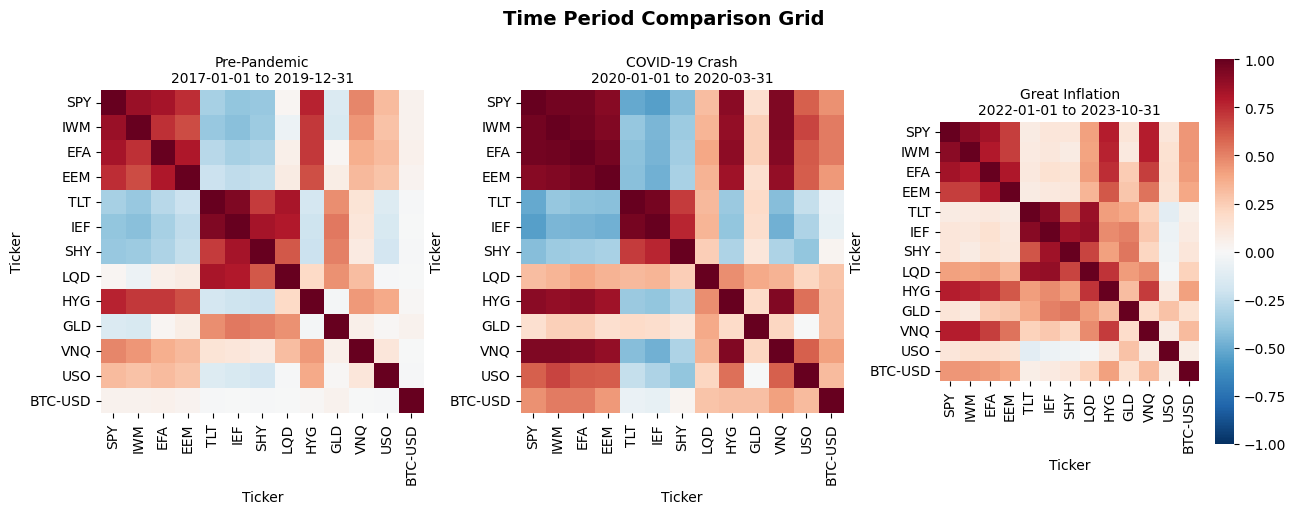

In [5]:
# Comparison between time periods through heatmaps
periods = ['Pre-Pandemic','COVID-19 Crash','Great Inflation']

times = {
    'Pre-Pandemic': ('2017-01-01','2019-12-31'),
    'COVID-19 Crash': ('2020-01-01','2020-03-31'),
    'Great Inflation': ('2022-01-01','2023-10-31')
}
# remove VIX from the tickers for correlation heatmap
tickers0 = ['SPY','IWM','EFA','EEM','TLT','IEF','SHY',
           'LQD','HYG','GLD','VNQ','USO','BTC-USD',]

# Create 3 subplots side by side
fig,axes = plt.subplots(1,3,figsize=(15,5))

for ax,name in zip(axes,periods):
    start,end = times[name]
    
    corr = returns.loc[start:end].corr().loc[tickers0,tickers0]
    
    # Draw heatmap
    sns.heatmap(
        corr,
        ax=ax,
        vmin=-1,vmax=1,           # same color scale for all
        cmap='RdBu_r',             # distinguish by red and blue(correlated and anti-correlated respectively)
        # annot=True,                # show numbers inside cells
        square=True,
        cbar=(name == 'Great Inflation')  # only show colorbar for the last plot
    )
    
    ax.set_title(f"{name}\n{start} to {end}", fontsize=10)

plt.suptitle("Time Period Comparison Grid", fontsize=14, fontweight='bold')
plt.subplots_adjust(wspace=0.3)
# plt.tight_layout()
plt.show()

In [6]:
# downloading the figure into an html file
import base64
from io import BytesIO

buf = BytesIO()
fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
image_base64 = base64.b64encode(buf.read()).decode('utf-8')
# html code

html = f"""<!DOCTYPE html>
<html>
    <img src="data:image/png;base64,{image_base64}">
</body>
</html>"""

with open('time_period_comparison.html', 'w') as f:
    f.write(html)

In [7]:
# Rolling 60-day correlation of every asset to SPY
rolling_corr = returns.rolling(60).corr()['SPY'].unstack(level=1)
rolling_corr = rolling_corr.dropna()
# rolling_corr

In [8]:
# # Plotting
# fig = rolling_corr[['GLD','BTC-USD','TLT']].plot(
#                                             title='Correlation matrix to S&P 500 (SPY) over time',
#                                             ylabel='Correlation',
#                                             xlabel='Date')

In [9]:
from plotly.subplots import make_subplots
fig2 = make_subplots(specs=[[{"secondary_y": True}]])

# Preparing to plot the diversifiers
hedge_assets = ['TLT', 'GLD', 'BTC-USD', 'IEF', 'SHY']
colors = {'TLT': '#1f77b4', 'GLD': '#ff7f0e', 'BTC-USD': '#2ca02c', 
          'IEF': '#9467bd', 'SHY': '#8c564b'}

In [10]:
# # check if there are any returns fitting the stress periods
# plt.plot(returns.index, returns['^VIX'], label='VIX Returns', color='red')
# plt.plot(returns.index, returns['SPY'], label='SPY Returns', color='blue')

In [11]:
# seperate the VIX levels
vix = data['^VIX']

# align VIX levels with returns
vix_aligned = vix.reindex(returns.index)
vix_aligned

Date
2017-01-04    11.85
2017-01-05    11.67
2017-01-06    11.32
2017-01-07      NaN
2017-01-08      NaN
              ...  
2025-12-26    13.60
2025-12-27      NaN
2025-12-28      NaN
2025-12-29    14.20
2025-12-30    14.33
Freq: D, Name: ^VIX, Length: 3283, dtype: float64

In [12]:
# distinguish between calm and stress periods based on VIX levels
calm = returns[vix_aligned < 20]
stress = returns[vix_aligned > 30]

In [13]:
# check hedge effectiveness during calm and stress periods
hedge_score = pd.DataFrame({
    'calm_corr': calm.corr()['SPY'],
    'stress_corr': stress.corr()['SPY']
})
hedge_score

,calm_corr,stress_corr
Ticker,,
BTC-USD,0.099291,0.518800
EEM,0.631769,0.892148
EFA,0.729991,0.933248
GLD,0.039180,0.203899
HYG,0.688857,0.818542
IEF,-0.035103,-0.314026
IWM,0.759491,0.944646
LQD,0.200803,0.360694
SHY,-0.005639,-0.185152


In [14]:
# Check the Betrayal ratio(stress correlation / calm correlation)
hedge_score['betrayal_ratio'] = hedge_score['stress_corr'] / hedge_score['calm_corr']
hedge_score

,calm_corr,stress_corr,betrayal_ratio
Ticker,,,
BTC-USD,0.099291,0.518800,5.225029
EEM,0.631769,0.892148,1.412142
EFA,0.729991,0.933248,1.278438
GLD,0.039180,0.203899,5.204166
HYG,0.688857,0.818542,1.188261
IEF,-0.035103,-0.314026,8.945865
IWM,0.759491,0.944646,1.243788
LQD,0.200803,0.360694,1.796260
SHY,-0.005639,-0.185152,32.835167


In [18]:
# plot key hedges / diversifiers(cell 9)

for asset in hedge_assets:
    if asset in rolling_corr.columns:
        fig2.add_trace(
            go.Scatter(
                x=rolling_corr.index,
                y=rolling_corr[asset],
                mode='lines',
                name=f"{asset} vs SPY",
                line=dict(width=2, color=colors.get(asset, '#333')),
                hovertemplate='%{x|%Y-%m-%d}<br>%{fullData.name}: %{y:.2f}<extra></extra>'
            ),
            secondary_y=False
        )

# Find VIX > 30 periods and group consecutive days
groups = []
if len(stress) > 0:
    stress_dates = stress.index
    current_group = [stress_dates[0]]
    
    for i in range(1, len(stress_dates)):
        if (stress_dates[i] - stress_dates[i-1]).days <= 3:
            current_group.append(stress_dates[i])
        else:
            groups.append((current_group[0], current_group[-1]))
            current_group = [stress_dates[i]]
    groups.append((current_group[0], current_group[-1]))

# Add red shaded stress zones
for start_date, end_date in groups:
    fig2.add_vrect(
        x0=start_date, 
        x1=end_date,
        fillcolor="red", 
        opacity=0.12,
        layer="below", 
        line_width=0
    )

# VIX as secondary axis
fig2.add_trace(
    go.Scatter(
        x=vix.index,
        y=vix,
        mode='lines',
        name='VIX Level',
        line=dict(width=1, color='red', dash='dot'),
        opacity=0.5,
        hovertemplate='%{x|%Y-%m-%d}<br>VIX: %{y:.1f}<extra></extra>'
    ),
    secondary_y=True
)

fig2.update_layout(
    title=dict(
        text="<b>Rolling 60-Day Correlation to SPY</b><br><sup>",
        x=0.5,
        y=0.97
    ),
    height=550, 
    width=1200,
    # legend=dict(
    #     orientation="h", 
    #     yanchor="bottom", 
    #     y=1.12, 
    #     xanchor="center", 
    #     x=0.5
    # ),
    hovermode="x unified",
    xaxis_rangeslider_visible=False
)

fig2.update_yaxes(title_text="Correlation to SPY",range=[-1,1],secondary_y=False)
fig2.update_yaxes(title_text="VIX Level",range=[0,90],secondary_y=True)

# Reference lines
fig2.add_hline(y=0,line_dash="dash",line_color="gray",opacity=0.5,secondary_y=False)
fig2.add_hline(y=0.5,line_dash="dot",line_color="red",opacity=0.3,secondary_y=False)

In [19]:
# download the figure into an html file
fig2.write_html("crisis_correlation.html")

In [ ]:
# Plot calm vs stress correlations using VIX LEVELS

# exclude SPY and VIX from the hedge_score for plotting
plot_assets = [t for t in tickers if t not in ['SPY', '^VIX']]
hs_plot = hedge_score.loc[plot_assets].copy()
# Betrayal ratio
hs_plot['betrayal_ratio'] = hs_plot['stress_corr'] / hs_plot['calm_corr'].replace(0, np.nan)

In [26]:
fig3 = go.Figure()

# Shading quadrants
min_val = min(hs_plot['calm_corr'].min(), hs_plot['stress_corr'].min()) - 0.1 
max_val = max(hs_plot['calm_corr'].max(), hs_plot['stress_corr'].max()) + 0.1 

# Bottom-right = TRUE HEDGE (anti-correlated in stress)
fig3.add_hrect(y0=min_val, y1=0, 
               fillcolor="green", opacity=0.08, 
               layer="below", line_width=0)

# Top-left = BETRAYAL (correlated in stress)
fig3.add_hrect(y0=0, y1=max_val, 
               fillcolor="red", opacity=0.08, 
               layer="below", line_width=0)

fig3.add_trace(
    go.Scatter(
        x=[min_val,max_val],
        y=[min_val,max_val],
        mode='lines',
        line=dict(color='gray',width=1,dash='dash'),
        name='No Change (45°)',
        hoverinfo='skip'
    )
)



In [29]:
# Color points by betrayal ratio:blue = stable,red = betrayed
colorscale_vals = np.log1p(np.abs(hs_plot['betrayal_ratio'].fillna(0)))

fig3.add_trace(
    go.Scatter(
        x=hs_plot['calm_corr'],
        y=hs_plot['stress_corr'],
        mode='markers+text',
        text=hs_plot.index,
        textposition="top center",
        marker=dict(
            size=16,
            color=hs_plot['stress_corr'] - hs_plot['calm_corr'],  # color by difference between stress and calm correlations
            colorscale='RdBu_r',
            cmin=-0.8, cmax=0.8,
            colorbar=dict(title="Stress - Calm",x=1.08),
            line=dict(width=1, color='black')
        ),
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Calm Corr: %{x:.2f}<br>"
            "Stress Corr: %{y:.2f}<br>"
            "Betrayal Ratio: %{customdata:.2f}<extra></extra>"
        ),
        customdata=hs_plot['betrayal_ratio'].values
    )
)

In [30]:
fig3.update_layout(
    title_text="<b>Hedge Effectiveness Scatter</b><br><sup>",
    title_x=0.5,
    height=650, width=800,
    xaxis_title="Correlation to SPY of Calm Markets (VIX < 20)",
    yaxis_title="Correlation to SPY of Stress Markets (VIX > 30)",
    xaxis=dict(range=[min_val, max_val], zeroline=True, zerolinecolor='gray'),
    yaxis=dict(range=[min_val, max_val], zeroline=True, zerolinecolor='gray', scaleanchor="x", scaleratio=1),
    showlegend=False,
    plot_bgcolor='rgba(240,240,240,0.3)'
)

In [31]:
# save scatter plot as html
fig3.write_html("hedge_effectiveness_scatter.html")